In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
import joblib
import torch

In [2]:
basepath = Path("/src/project/data/experiment")
exc_save_fname = basepath / "exc_images_preprocessed.npy"
images = np.load(exc_save_fname, allow_pickle=True)

In [3]:
images.shape

(960, 36, 36)

In [8]:
h, w = images.shape[1:]
crops = np.array(
    [
        images[:, i * h // 3 : (i + 1) * h // 3, j * w // 3 : (j + 1) * w // 3]
        for i in range(3)
        for j in range(3)
    ]
)
crops = crops.reshape((*crops.shape[:-2], -1))
print(crops.shape)

(9, 960, 144)


In [9]:
data_basepath = Path("/src/project/data/ica/repeat_9_crop_12_comp_40")
X_I_models_path = data_basepath / "layer2_models"
X_I_models = []
for entry in X_I_models_path.iterdir():
    # go through files and load joblib files
    if entry.is_file() and entry.suffix == ".joblib":
        model = joblib.load(entry)
        X_I_models.append(model)

In [14]:
all_X_mixing_ = np.array([model.mixing_ for model in X_I_models])
all_X_mixing_ = all_X_mixing_.transpose(0, 2, 1)
print(all_X_mixing_.shape)

(9, 40, 144)


In [15]:
cosine_sim_matrix = []
for mixing, patch in zip(all_X_mixing_, crops):
    # print(cosine_similarity(mixing, patch).shape)
    # break
    # The line `cosine_sim_matrix.append(cosine_similarity(mixing, patch))` is calculating the cosine similarity between the `mixing` and `patch` vectors and appending the result to the `cosine_sim_matrix` list.
    cosine_sim_matrix.append(cosine_similarity(mixing, patch))

In [16]:
cosine_sim_matrix = np.array(cosine_sim_matrix)
print(cosine_sim_matrix.shape)

(9, 40, 960)


In [46]:
min_patch = np.min(patches)
max_patch = np.max(patches)
min_patch, max_patch

(0.1764705882352941, 0.8450980392156862)

In [48]:
min_filter = np.min(X_I_filters)
max_filter = np.max(X_I_filters)
min_filter, max_filter

(-59.270414424125796, 59.20413255410975)

(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)


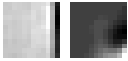

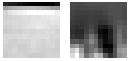

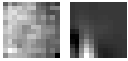

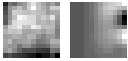

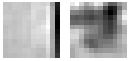

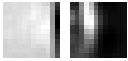

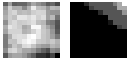

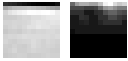

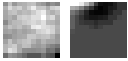

In [54]:
all_relevant_filters = []
for patch_set in patches:
    relevant_filters = []
    patch_set = patch_set.reshape(9, -1)
    # print(patch_set.shape)
    for filter_set, patch in zip(X_I_filters, patch_set):
        # print(filter_set.shape, patch.shape)
        similarities = cosine_similarity(filter_set.T, patch.reshape(1, -1))
        print(similarities.shape)
        # print(np.argmax(similarities))
        fig, axs = plt.subplots(1, 2, dpi=25)
        filter = filter_set.T[np.argmax(similarities)]
        filter_min = np.min(filter)
        filter_max = np.max(filter)
        patch_min = np.min(patch)
        patch_max = np.max(patch)
        axs[0].imshow(
            filter.reshape(12, 12), cmap="gray", vmin=filter_min, vmax=filter_max
        )
        axs[0].axis("off")
        axs[1].imshow(
            patch.reshape(12, 12), cmap="gray", vmin=patch_min, vmax=patch_max
        )
        axs[1].axis("off")
        # relevant_filters.append(np.argmax(similarities))
        # for filter in filter_set.T:
        #     similarities = cosine_similarity(filter_set, patch_set.reshape(1, -1))
        #     relevant_filters.append(np.argmax(similarities))

(12, 12)


(-0.5, 11.5, 11.5, -0.5)

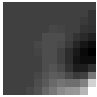

In [61]:
first_patch = patches[0][0]
print(first_patch.shape)
fig, ax = plt.subplots(dpi=25)
ax.imshow(first_patch, cmap="gray")
ax.axis("off")

(40, 144)


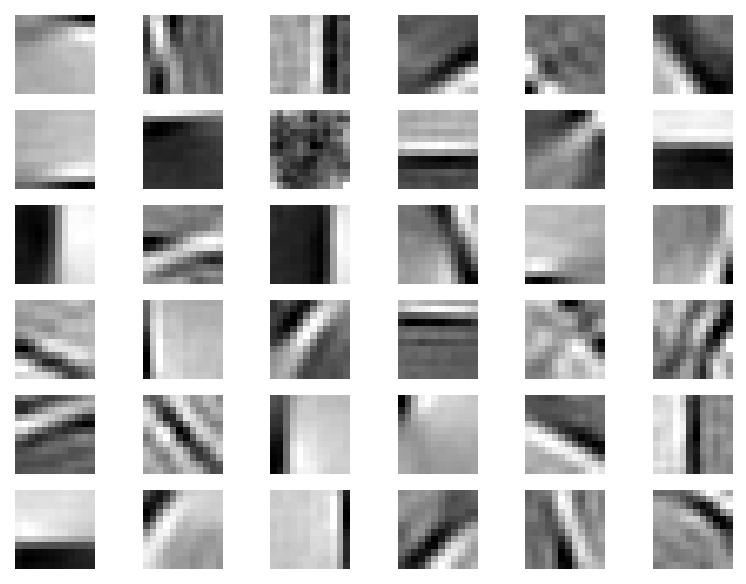

In [63]:
first_filter_set = X_I_filters[0].T
print(first_filter_set.shape)
fig, axs = plt.subplots(6, 6, dpi=150)
for idx, ax in enumerate(axs.flatten()):
    ax.imshow(first_filter_set[idx].reshape(12, 12), cmap="gray")
    ax.axis("off")

In [65]:
similarities = cosine_similarity(first_patch.reshape(1, -1), first_filter_set)

In [67]:
similarities.shape

(1, 40)

(-0.5, 11.5, 11.5, -0.5)

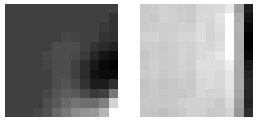

In [70]:
fig, axs = plt.subplots(1, 2, dpi=50)
axs[0].imshow(first_patch.reshape(12, 12), cmap="gray")
axs[0].axis("off")
axs[1].imshow(first_filter_set[np.argmax(similarities)].reshape(12, 12), cmap="gray")
axs[1].axis("off")

In [ ]:
second_patch = patches[0][2]
print(first_patch.shape)
fig, ax = plt.subplots(dpi=25)
ax.imshow(first_patch, cmap="gray")
ax.axis("off")